# EDA: CLINC150
Разведочный анализ датасета для классификации интентов.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from datasets import load_dataset
import os

os.makedirs('../results/eda', exist_ok=True)
plt.rcParams['figure.dpi'] = 150

## 1. Загрузка данных

In [27]:
dataset = load_dataset('clinc_oos', 'plus')

In [28]:
train_df = pd.read_csv("../data/splits/train.csv")
val_df = pd.read_csv("../data/splits/val.csv")
test_df = pd.read_csv("../data/splits/test.csv")

In [29]:
print(f'Train: {len(train_df)} примеров')
print(f'Val:   {len(val_df)} примеров')
print(f'Test:  {len(test_df)} примеров')

Train: 16694 примеров
Val:   3578 примеров
Test:  3578 примеров


In [30]:
train_df.head()

,text,intent
0,don't do this process,147
1,how do i use the reward for my bank of hawaii,6
2,what time is today's meeting,19
3,what stuff did i put on my shopping list,43
4,is that restaurant crowded during dinner,102


## 2. Маппинг меток

In [31]:
label_names = dataset['train'].features['intent'].names
train_df['intent_name'] = train_df['intent'].map(lambda x: label_names[x])
test_df['intent_name']  = test_df['intent'].map(lambda x: label_names[x])

print(f'Всего классов: {len(label_names)}')

Всего классов: 151


## 3. Распределение по доменам

In [32]:
domain_map = {
    'banking':        ['transfer', 'transactions', 'balance', 'freeze_account', 'pay_bill',
                       'bill_balance', 'bill_due', 'interest_rate', 'routing', 'min_payment',
                       'new_card', 'order_checks', 'pin_change', 'report_fraud', 'spending_history'],
    'credit_cards':   ['credit_score', 'report_lost_card', 'credit_limit', 'rewards_balance',
                       'application_status', 'card_declined', 'international_fees', 'apr',
                       'redeem_rewards', 'credit_limit_change', 'damaged_card',
                       'replacement_card_duration', 'improve_credit_score', 'expiration_date',
                       'account_blocked'],
    'kitchen':        ['recipe', 'nutrition_info', 'calories', 'ingredients_list', 'cook_time',
                       'food_last', 'meal_suggestion', 'ingredient_substitution',
                       'restaurant_reviews', 'accept_reservations', 'restaurant_reservation',
                       'restaurant_suggestion', 'cancel_reservation', 'confirm_reservation',
                       'order', 'order_status'],
    'auto':           ['oil_change_how', 'oil_change_when', 'jump_start', 'tire_change',
                       'tire_pressure', 'car_rental', 'gas', 'gas_type', 'mpg', 'uber',
                       'traffic', 'directions', 'last_maintenance', 'schedule_maintenance', 'distance'],
    'travel':         ['book_flight', 'book_hotel', 'carry_on', 'lost_luggage', 'travel_alert',
                       'travel_notification', 'travel_suggestion', 'plug_type', 'timezone',
                       'flight_status', 'international_visa', 'exchange_rate', 'vaccines',
                       'cancel', 'insurance'],
    'home':           ['smart_home', 'alarm', 'timer', 'reminder', 'reminder_update',
                       'calendar', 'calendar_update', 'todo_list', 'todo_list_update',
                       'shopping_list', 'shopping_list_update', 'play_music', 'update_playlist',
                       'next_song', 'what_song'],
    'utility':        ['calculator', 'measurement_conversion', 'time', 'date', 'next_holiday',
                       'current_location', 'find_phone', 'share_location', 'definition',
                       'spelling', 'translate', 'change_language', 'sync_device',
                       'change_volume', 'change_speed', 'weather'],
    'work':           ['schedule_meeting', 'meeting_schedule', 'pto_request', 'pto_balance',
                       'pto_used', 'pto_request_status', 'income', 'taxes', 'payday',
                       'w2', 'rollover_401k', 'direct_deposit', 'insurance_change',
                       'how_busy', 'change_user_name'],
    'meta':           ['who_made_you', 'who_do_you_work_for', 'are_you_a_bot', 'what_is_your_name',
                       'where_are_you_from', 'how_old_are_you', 'what_are_your_hobbies',
                       'what_can_i_ask_you', 'meaning_of_life', 'do_you_have_pets',
                       'change_ai_name', 'change_accent', 'change_speed', 'reset_settings',
                       'user_name'],
    'small_talk':     ['greeting', 'goodbye', 'thank_you', 'yes', 'no', 'maybe',
                       'tell_joke', 'fun_fact', 'flip_coin', 'roll_dice', 'repeat',
                       'whisper_mode', 'text', 'make_call', 'how_old_are_you'],
}

intent_to_domain = {
    intent: domain
    for domain, intents in domain_map.items()
    for intent in intents
}

train_df['domain'] = train_df['intent_name'].map(
    lambda x: 'oos' if x == 'oos' else intent_to_domain.get(x, 'unknown')
)

unknown = train_df[train_df['domain'] == 'unknown']['intent_name'].unique()
print(f'Без домена: {unknown if len(unknown) else "OK"}')
train_df[['text', 'intent_name', 'domain']].head()

Без домена: OK


,text,intent_name,domain
0,don't do this process,cancel,travel
1,how do i use the reward for my bank of hawaii,redeem_rewards,credit_cards
2,what time is today's meeting,meeting_schedule,work
3,what stuff did i put on my shopping list,shopping_list,home
4,is that restaurant crowded during dinner,how_busy,work


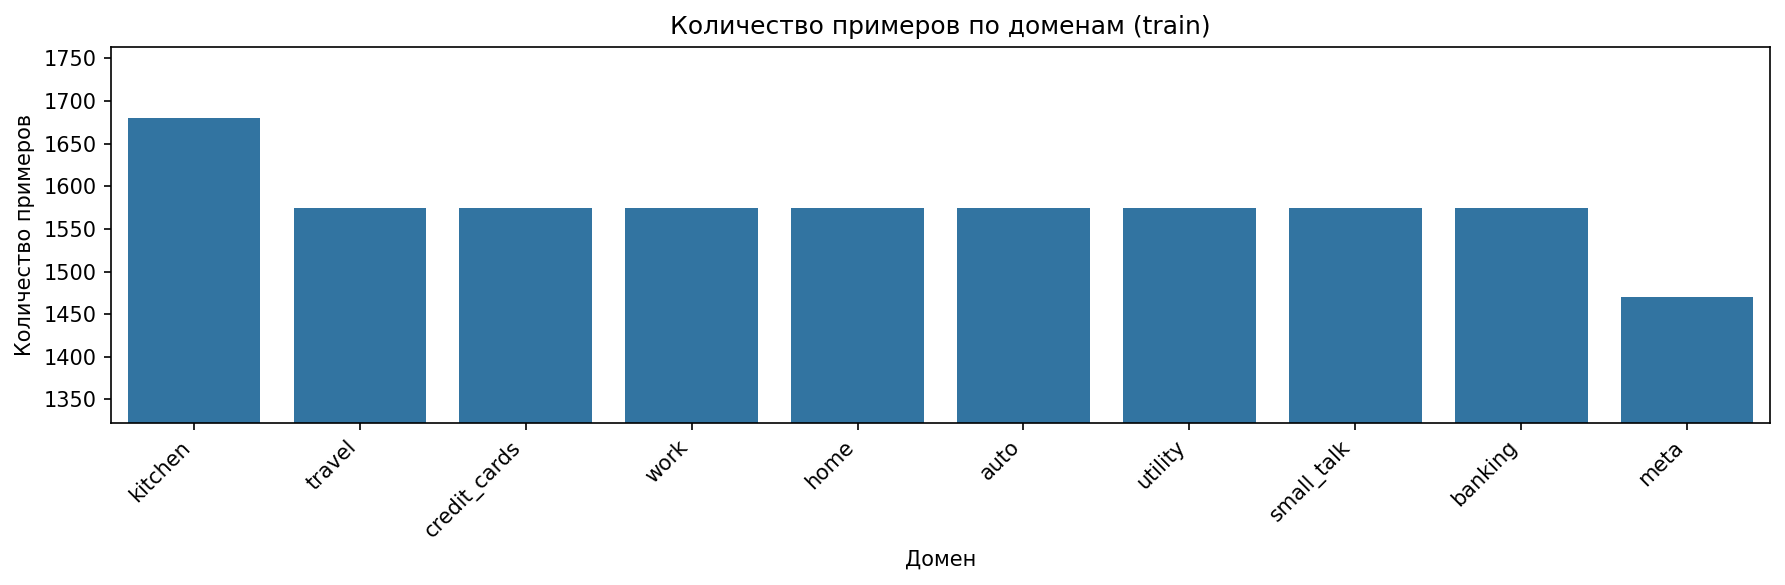

In [33]:
domain_counts = train_df[train_df['domain'] != 'oos']['domain'].value_counts().reset_index().sort_values('count', ascending=False)
domain_counts.columns = ['domain', 'count']

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=domain_counts, x='domain', y='count', ax=ax)
ax.set(title='Количество примеров по доменам (train)', xlabel='Домен', ylabel='Количество примеров')
ax.set_ylim(domain_counts['count'].min() * 0.9, domain_counts['count'].max() * 1.05)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/eda/domain_distribution.png')
plt.show()

## 4. Длина запросов

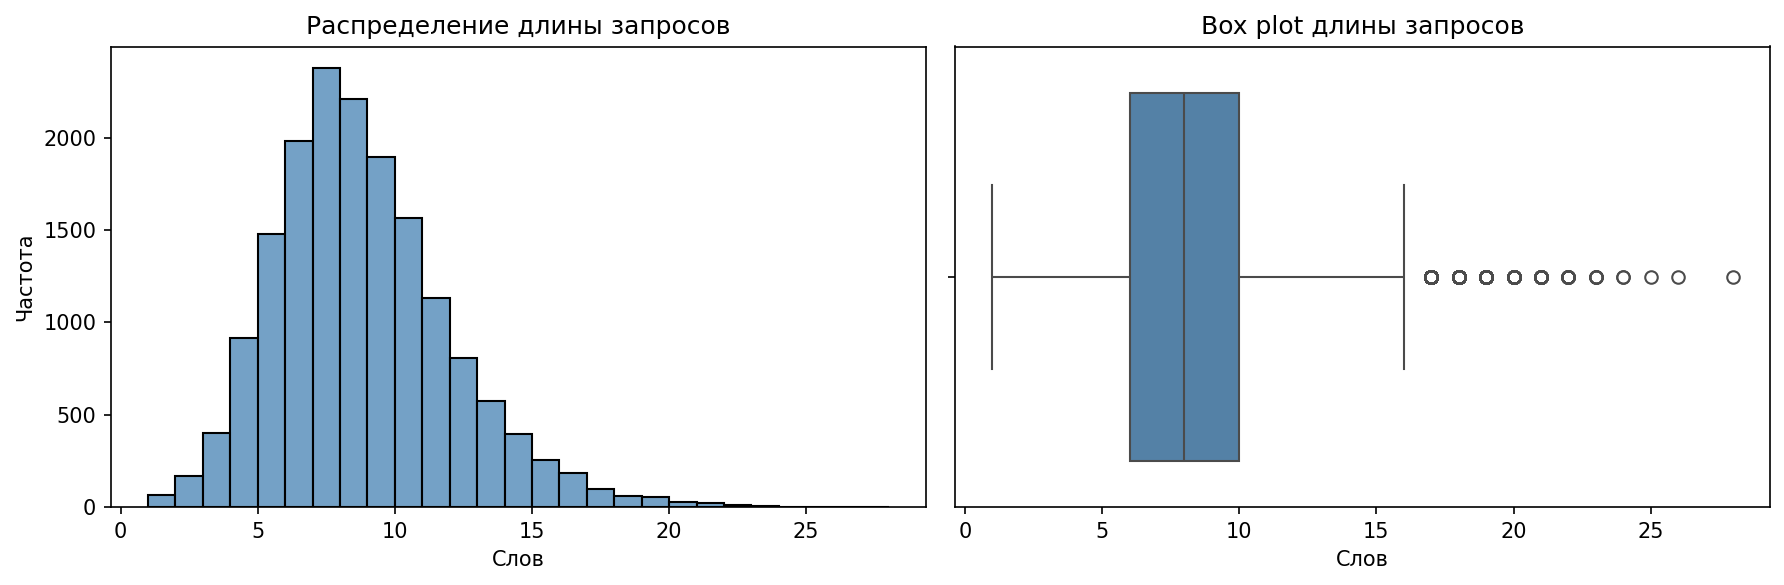

In [34]:
train_df['text_len'] = train_df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_df['text_len'], bins=27, color='steelblue', ax=axes[0])
axes[0].set(title='Распределение длины запросов', xlabel='Слов', ylabel='Частота')
sns.boxplot(x=train_df['text_len'], ax=axes[1], color='steelblue')
axes[1].set(title='Box plot длины запросов', xlabel='Слов')
plt.tight_layout()
plt.savefig('../results/eda/text_length_distribution.png')
plt.show()

## 5. Облако слов

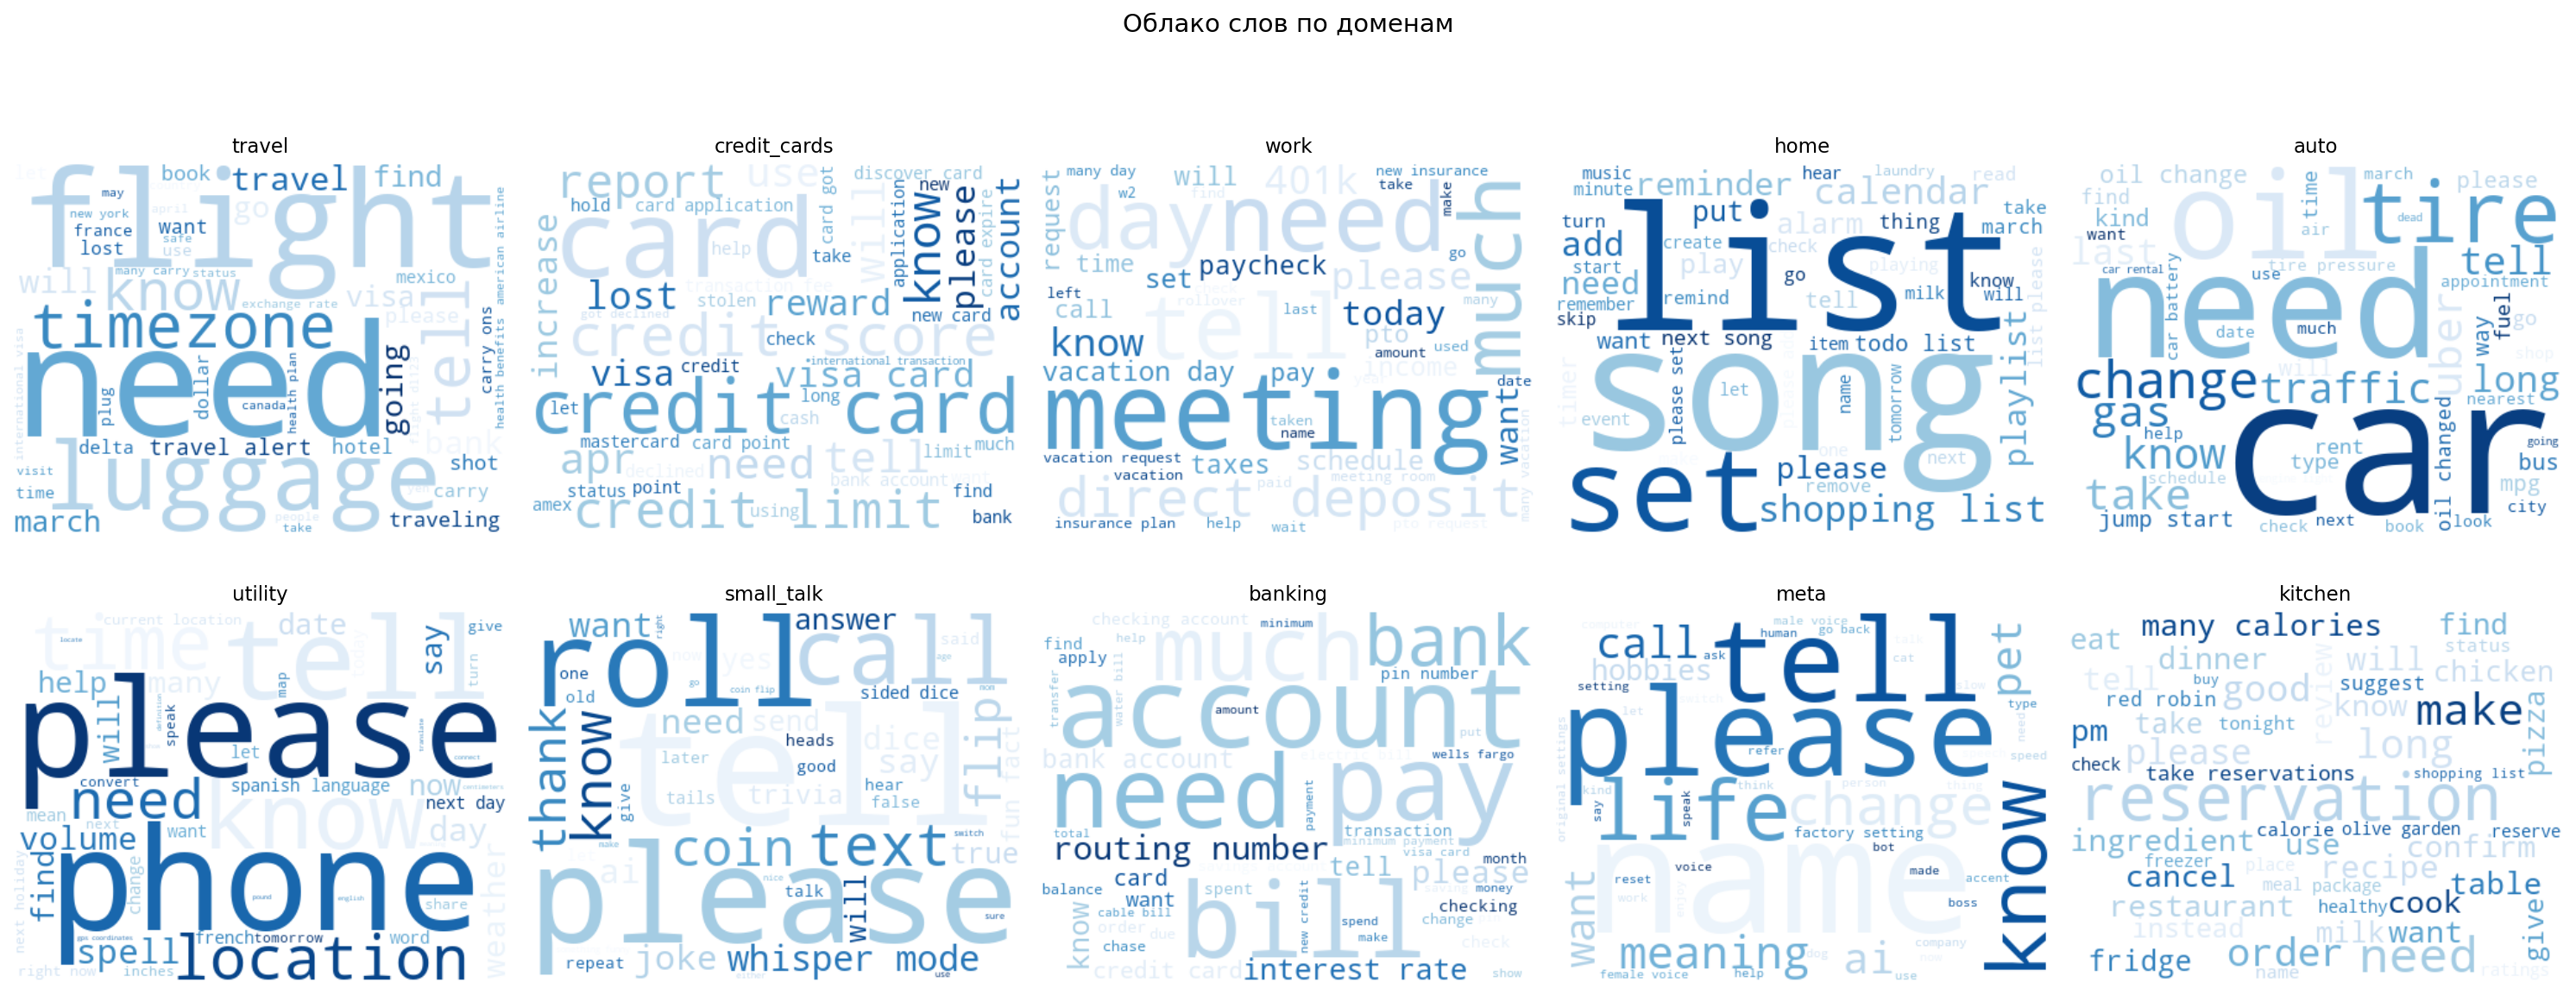

In [35]:
domains = [d for d in train_df['domain'].unique() if d != 'oos']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, domain in zip(axes, domains):
    text = ' '.join(train_df[train_df['domain'] == domain]['text'])
    wc = WordCloud(width=400, height=300, background_color='white',
                   colormap='Blues', max_words=50).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(domain, fontsize=11)

plt.suptitle('Облако слов по доменам', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/eda/wordclouds_by_domain.png', bbox_inches='tight')
plt.show()